# Evaluation and Comparison of Features

In this notebook we explore the impact of existing features on target in a comparison to new features.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [2]:
# --- STEP 1: Load Data ---
X_raw = pd.read_csv("../data/raw/Training_Set_Values.csv")
y_raw = pd.read_csv("../data/raw/Training_Set_Labels.csv")

# Merge on 'id' if needed (ensure labels are aligned)
df = X_raw.merge(y_raw, on="id")
print("df:",df.shape)

df: (59400, 41)


In [3]:
categorical_columns = [
   'subvillage','lga','ward', 'basin','management_group','payment_type','source_class', 'waterpoint_type'
] # 'funder_grouped', 'installer_grouped', 'extraction_type_group','extraction_type_class','source_type',

for column in categorical_columns:
    df[column], _ = pd.factorize(df[column])

In [4]:
# Map the categorical values to numerical values
status_mapping = {'functional': 2, 'non functional': 0, 'functional needs repair': 1}
df['status_group'] = df['status_group'].map(status_mapping)

# Calculate the correlation matrix
correlation_matrix = df.select_dtypes(include='number').corr()

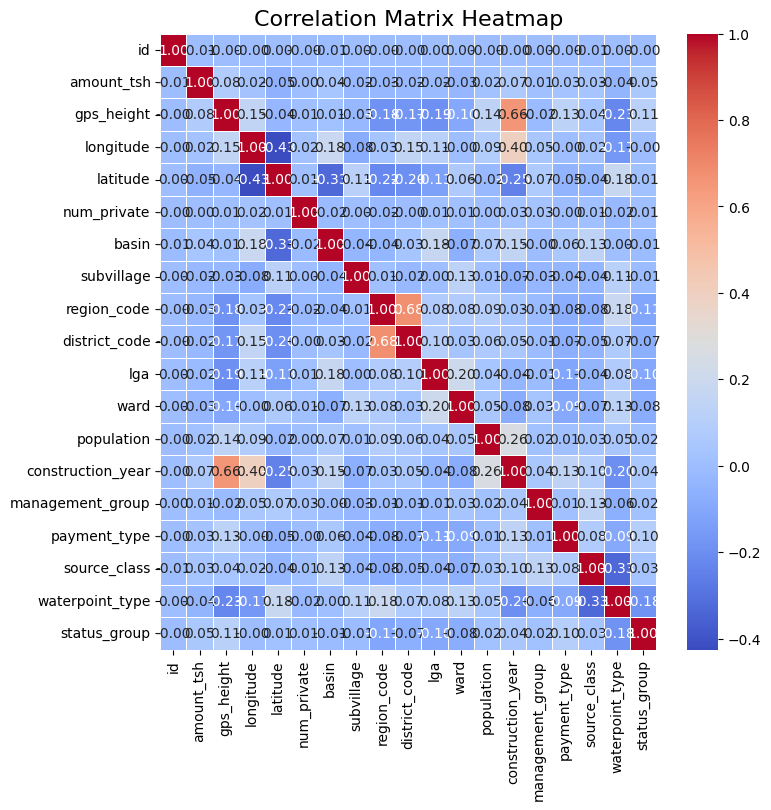

In [5]:
# Set up the matplotlib figure
plt.figure(figsize=(8, 8))

# Create the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Add a title
plt.title("Correlation Matrix Heatmap", fontsize=16)

# Show the plot
plt.show()

In [6]:
# Simple encoding
df = df.drop(columns=['recorded_by'],axis=1)
df = df.fillna('missing')

# Convert all object and bool columns to strings before encoding
for col in df.select_dtypes(include=['object', 'bool']).columns:
    df[col] = df[col].astype(str)
    df[col] = LabelEncoder().fit_transform(df[col])

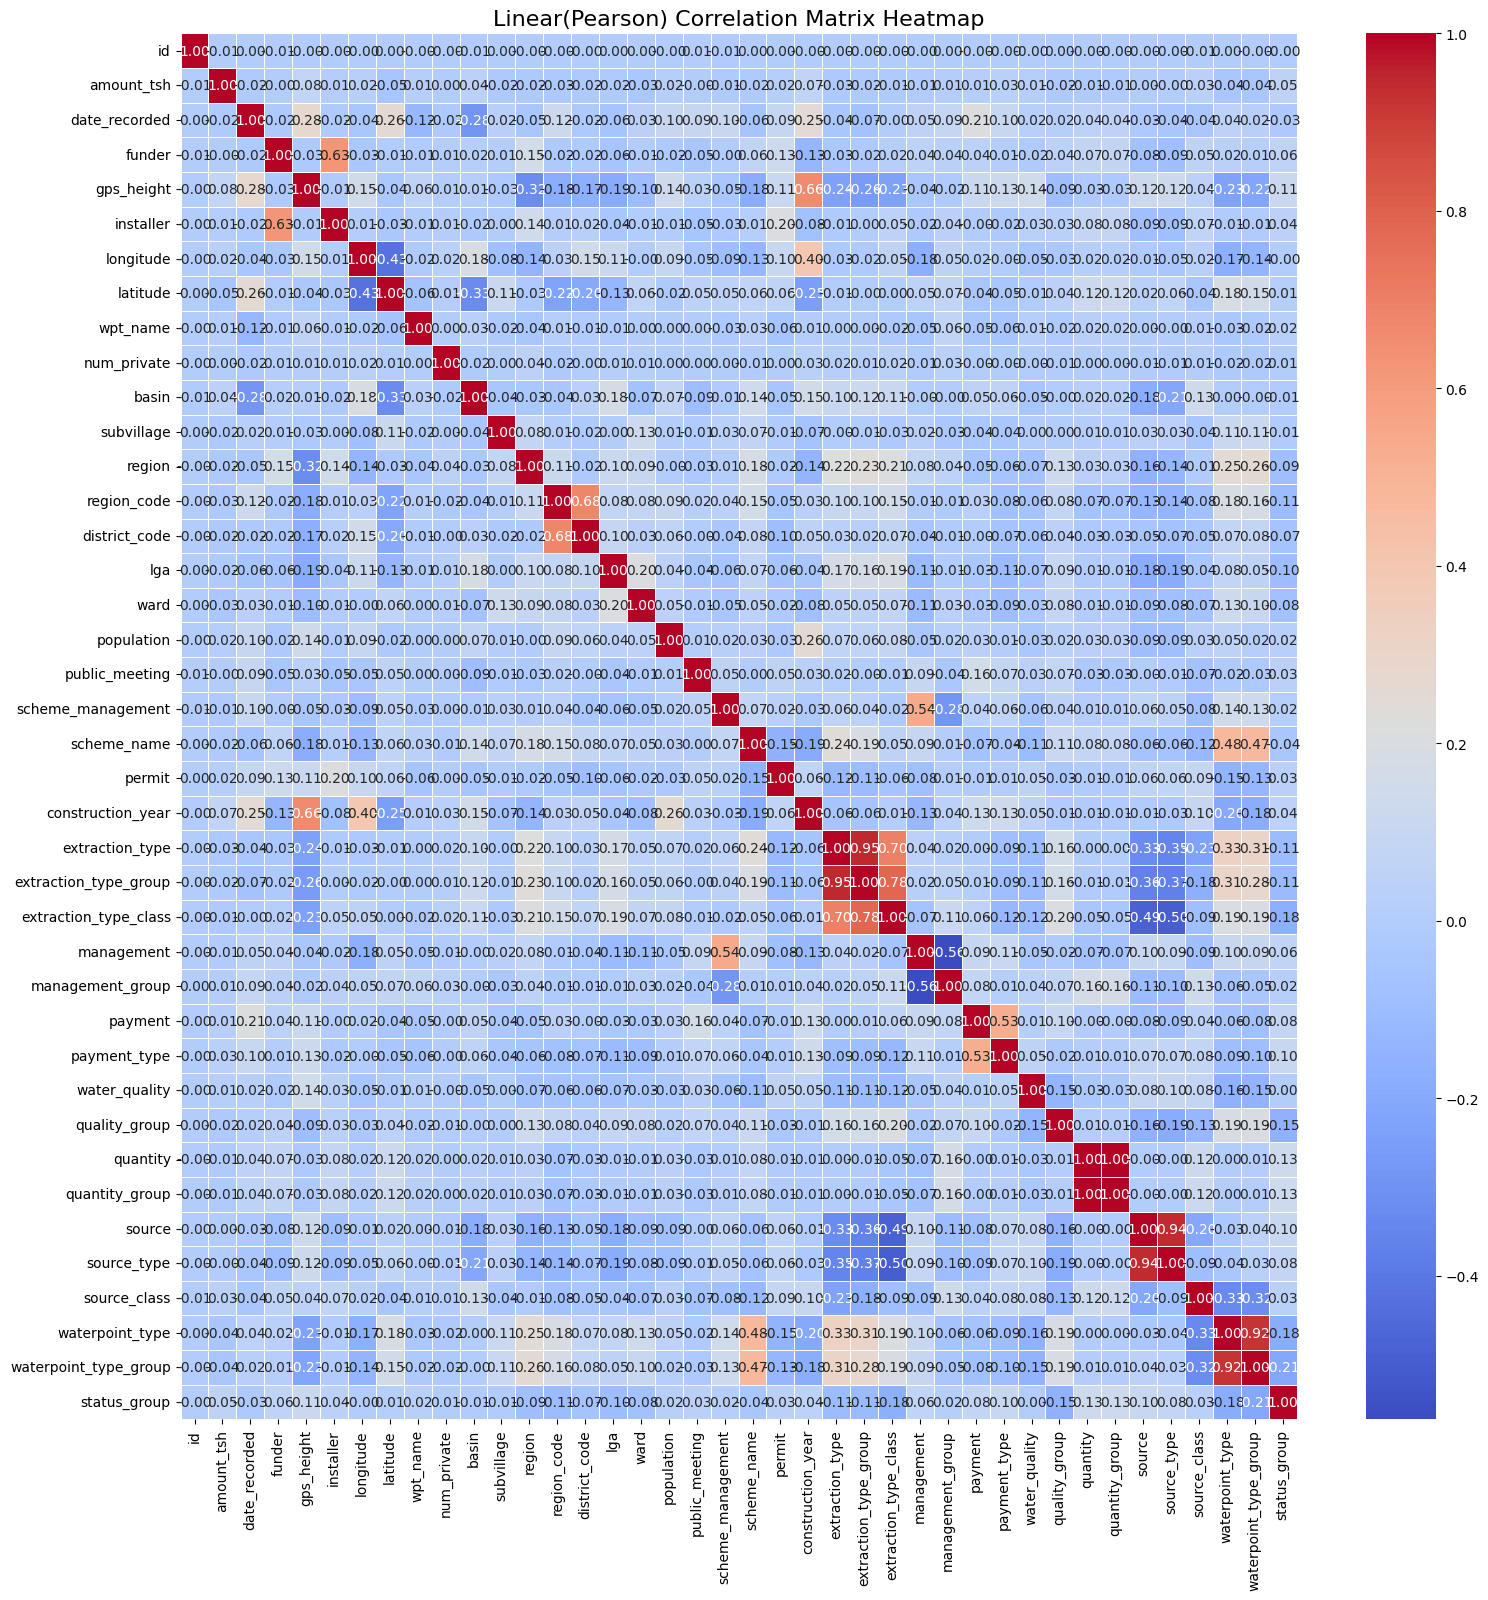

In [7]:
# Recalculate the correlation matrix
correlation_matrix = df.select_dtypes(include='number').corr()

# Set up the matplotlib figure
plt.figure(figsize=(18, 18))

# Create the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Add a title
plt.title("Linear(Pearson) Correlation Matrix Heatmap", fontsize=16)

# Show the plot
plt.show()

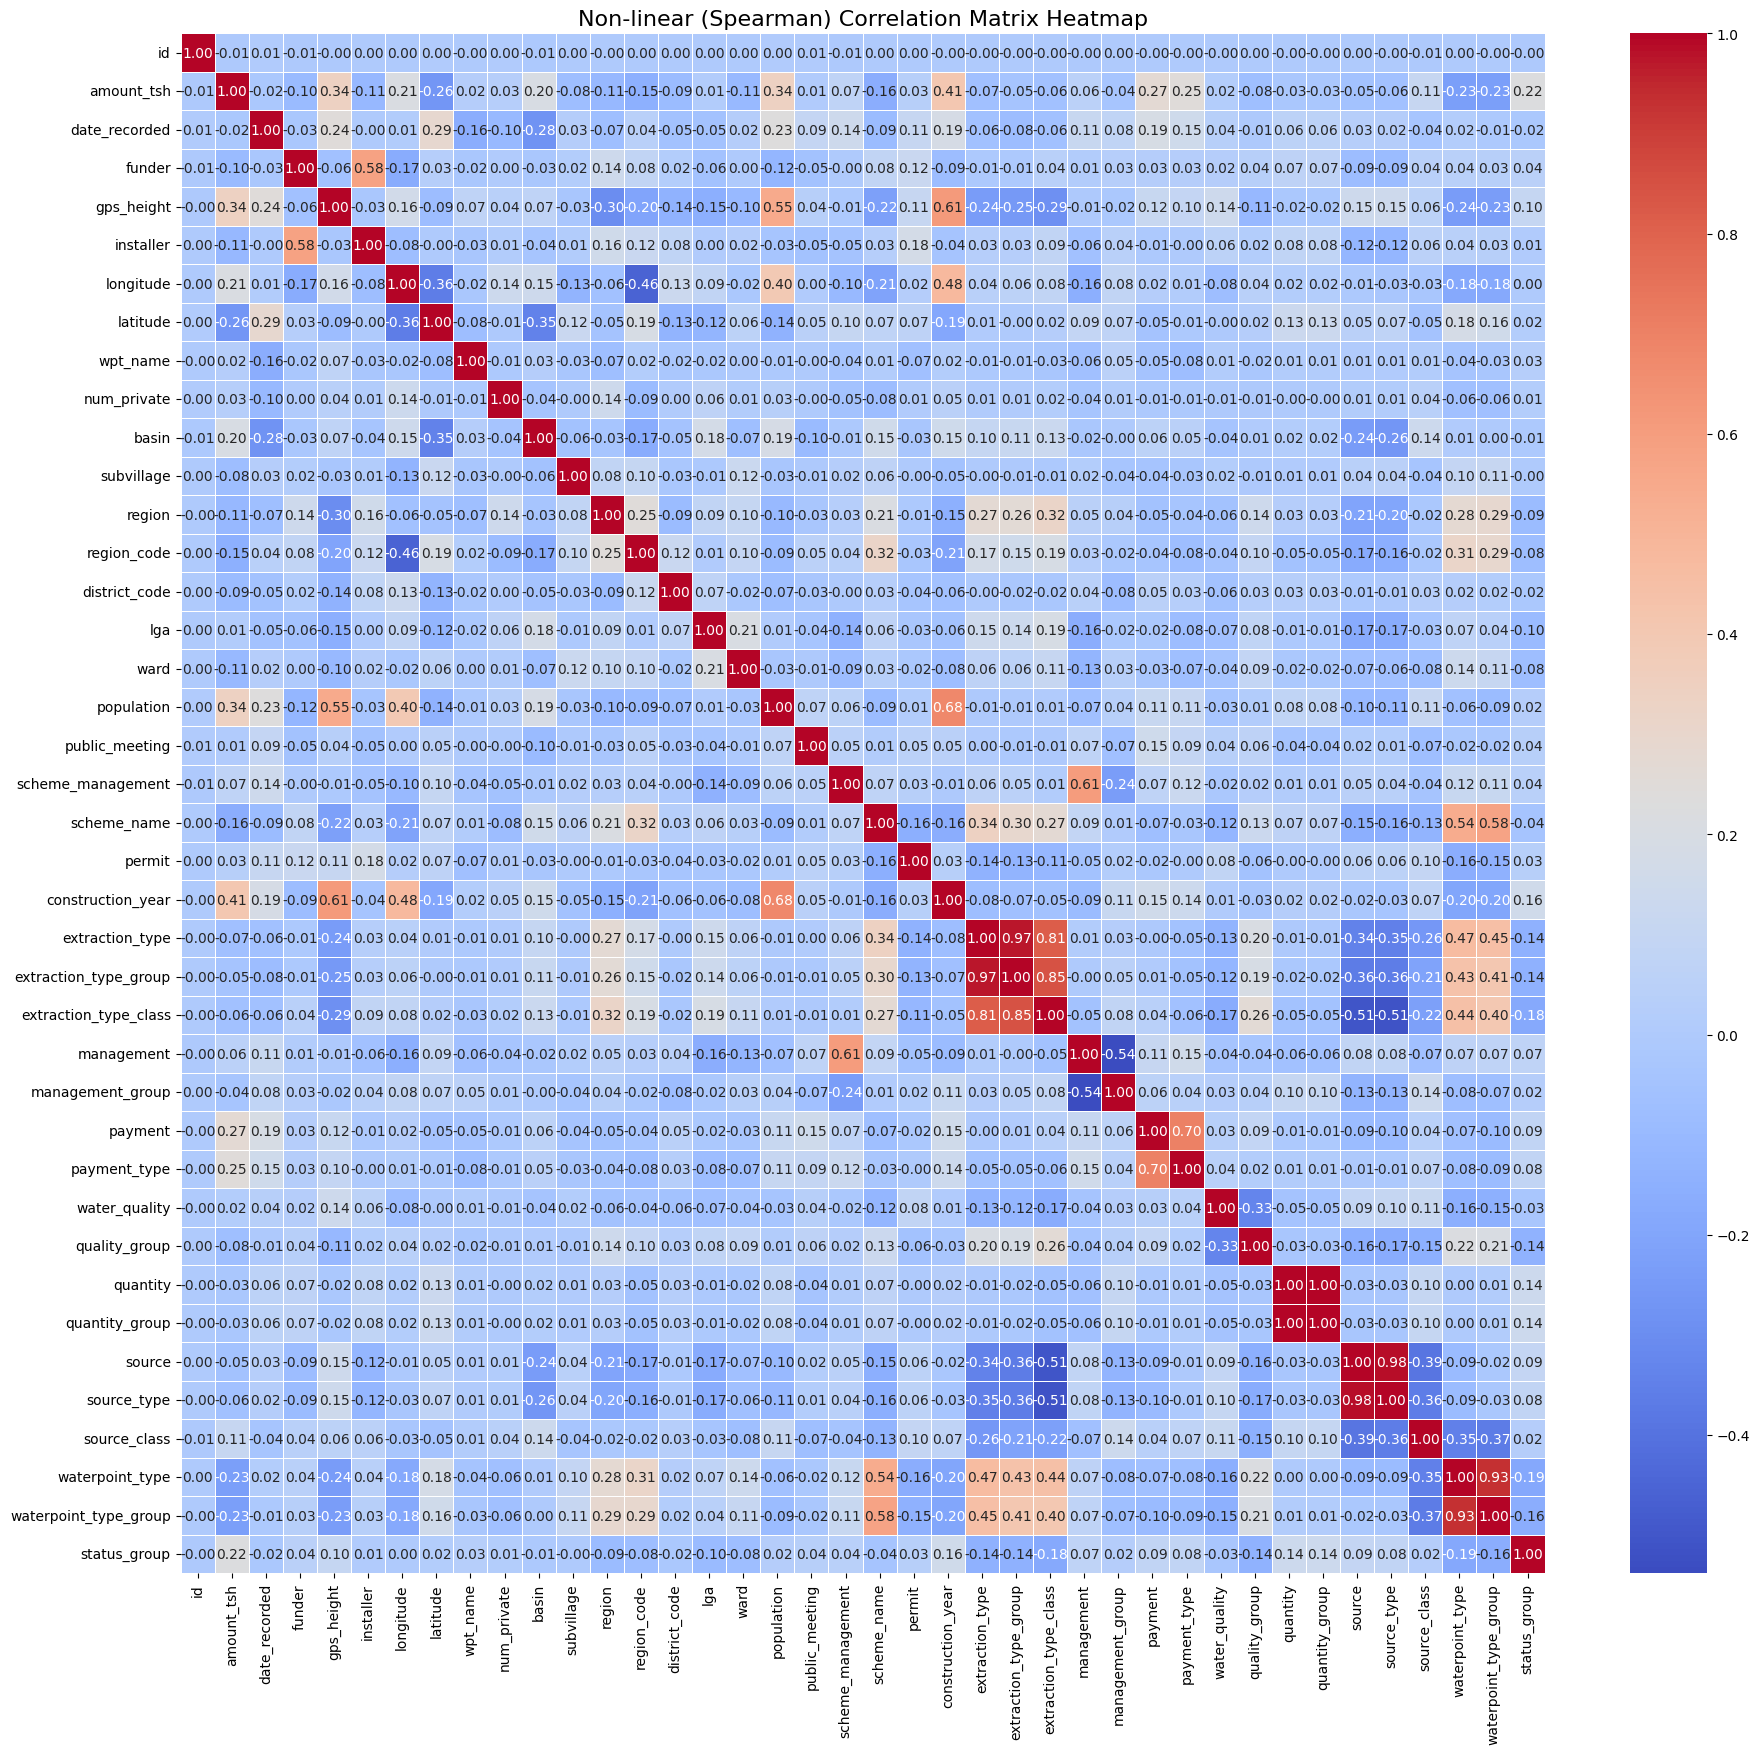

In [8]:
# Recalculate the correlation matrix
correlation_matrix = df.select_dtypes(include='number').corr(method='spearman')

# Set up the matplotlib figure
plt.figure(figsize=(22, 20))

# Create the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Add a title
plt.title("Non-linear (Spearman) Correlation Matrix Heatmap", fontsize=16)

# Show the plot
plt.show()

## Feature Selection

Feature selection is a crucial step in the machine learning pipeline. It involves selecting the most important features from your dataset to improve model performance and reduce computational cost. In this article, we will explore various techniques for feature selection in Python using the Scikit-Learn library.

#### What is feature selection?
Feature selection is the process of identifying and selecting a subset of relevant features for use in model construction. The goal is to enhance the model's performance by reducing overfitting, improving accuracy, and reducing training time.

#### Why is Feature Selection Important?
Feature selection offers several benefits:

- Improved Model Performance: By removing irrelevant or redundant features, we can improve the accuracy of the model.
- Reduced Overfitting: With fewer features, the model is less likely to learn noise from the training data.
- Faster Computation: Reducing the number of features decreases the computational cost and training time.

#### Types of Feature Selection Methods

Feature selection methods can be broadly classified into three categories:

- Filter Methods: Filter methods use statistical techniques to evaluate the relevance of features independently of the model. Common techniques include correlation coefficients, chi-square tests, and mutual information.
- Wrapper Methods: Wrapper methods use a predictive model to evaluate feature subsets and select the best-performing combination. Techniques include recursive feature elimination (RFE) and forward/backward feature selection.
- Embedded Methods: Embedded methods perform feature selection during the model training process. Examples include Lasso (L1 regularization) and feature importance from tree-based models.
- Feature Selection Techniques with Scikit-Learn


__Scikit-Learn provides several tools for feature selection, including:__

- Univariate Selection: Univariate selection evaluates each feature individually to determine its importance. Techniques like SelectKBest and SelectPercentile can be used to select the top features based on statistical tests.
- Recursive Feature Elimination (RFE): RFE is a wrapper method that recursively removes the least important features based on a model's performance. It repeatedly builds a model and eliminates the weakest features until the desired number of features is reached.
- Feature Importance from Tree-based Models: Tree-based models like decision trees and random forests can provide feature importance scores, indicating the importance of each feature in making predictions.

In [9]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def compute_mutual_information(df, target_col):
    df_encoded = df.copy()
    
    # Encode categorical columns
    for col in df_encoded.columns:
        if df_encoded[col].dtype == 'object' or df_encoded[col].dtype.name == 'category':
            df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))
    
    X = df_encoded.drop(columns=[target_col])
    y = df_encoded[target_col]

    # Ensure y is encoded
    if y.dtype == 'object' or y.dtype.name == 'category':
        y = LabelEncoder().fit_transform(y.astype(str))
    
    # Compute mutual information
    mi_scores = mutual_info_classif(X, y, discrete_features='auto')
    
    # Create a DataFrame for easier handling
    mi_df = pd.DataFrame({'Feature': X.columns, 'MI Score': mi_scores})
    mi_df = mi_df.sort_values(by='MI Score', ascending=False).reset_index(drop=True)
    return mi_df


In [10]:
def plot_mutual_information(mi_df, top_n=20):
    plt.figure(figsize=(10, 8))
    sns.barplot(data=mi_df.head(top_n), x='MI Score', y='Feature', palette='viridis')
    plt.title(f"Top {top_n} Features by Mutual Information with Target")
    plt.tight_layout()
    plt.show()


In [51]:
df.drop(columns=['source_type','source_class'], inplace=True)

/var/folders/dy/n44rnxw55t54k5zb19w3gz7m0000gn/T/ipykernel_1365/93040470.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df.head(top_n), x='MI Score', y='Feature', palette='viridis')


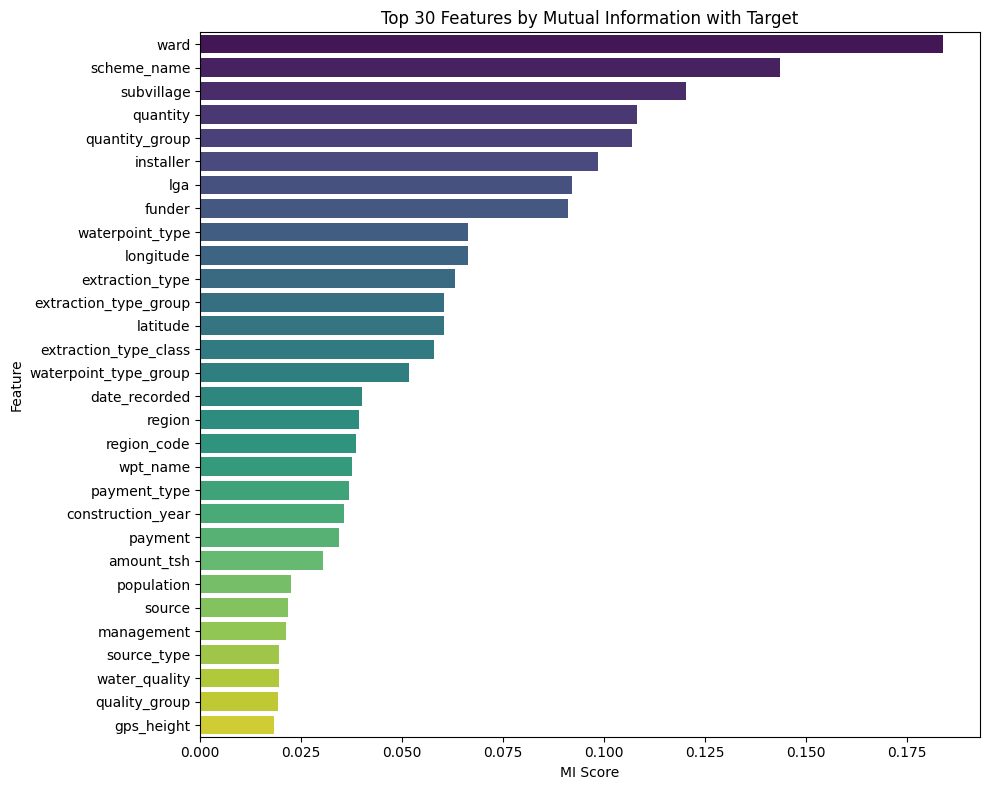

In [11]:
mi_df = compute_mutual_information(df, 'status_group')
plot_mutual_information(mi_df, top_n=30)


In [12]:
from sklearn.feature_selection import mutual_info_classif

X = df.drop('status_group',axis=1)  # Include all features you're evaluating
y = df['status_group']   # This should be label-encoded if it's categorical

# Encode categorical features as needed, and set discrete features manually or use auto
mi_scores = mutual_info_classif(X, y, discrete_features='auto', random_state=0)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print(mi_series.head(30))


ward                     0.181837
scheme_name              0.145867
subvillage               0.121281
quantity_group           0.107191
quantity                 0.106225
installer                0.098267
lga                      0.091833
funder                   0.091336
waterpoint_type          0.067644
longitude                0.067093
extraction_type_group    0.063989
latitude                 0.061150
extraction_type_class    0.061139
extraction_type          0.060320
waterpoint_type_group    0.056274
region                   0.044339
region_code              0.043544
date_recorded            0.037135
payment_type             0.036914
wpt_name                 0.036884
construction_year        0.036569
amount_tsh               0.036440
payment                  0.036065
quality_group            0.024264
water_quality            0.023607
source                   0.022965
population               0.019475
management               0.019055
source_type              0.018028
basin         